In [1]:
from torch.optim.lr_scheduler import OneCycleLR

def create_onecycle_scheduler_v2(
    optimizer,
    max_lr,
    total_steps,
    warmup_fraction=0.3,
    initial_lr_fraction=0.1,
    final_lr_fraction=0.01
):
    """
    Creates a OneCycleLR scheduler with warmup and cosine decay.
    
    Args:
        optimizer: The optimizer to use
        max_lr: Maximum learning rate after warmup
        total_steps: Total number of training steps
        warmup_fraction: Fraction of total steps used for warmup (default: 0.3)
        initial_lr_fraction: Fraction of max_lr to use as the initial learning rate (default: 0.1)
        final_lr_fraction: Fraction of max_lr to use as the final learning rate (default: 0.01)
    """
    return OneCycleLR(
        optimizer,
        max_lr=max_lr,
        total_steps=total_steps,
        pct_start=warmup_fraction,
        div_factor=1 / initial_lr_fraction,
        final_div_factor=1 / (initial_lr_fraction * final_lr_fraction),
        anneal_strategy='cos'
    )

/Users/C5384663/.pyenv/versions/3.12.7/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


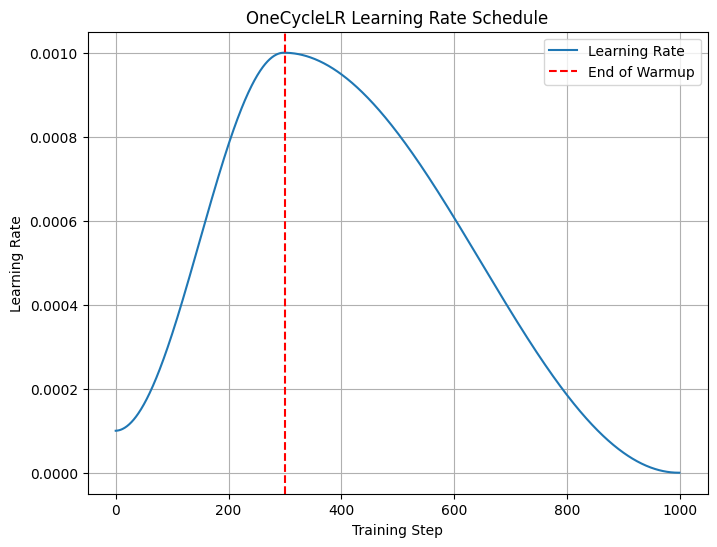

In [2]:
import torch
import matplotlib.pyplot as plt

# Define a dummy optimizer
model = torch.nn.Linear(10, 1)  # Dummy model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Create the scheduler
total_steps = 1000
scheduler = create_onecycle_scheduler_v2(
    optimizer,
    max_lr=1e-3,
    total_steps=total_steps,
    warmup_fraction=0.3,
    initial_lr_fraction=0.1,
    final_lr_fraction=0.01
)

# Track learning rates
lrs = []
for step in range(total_steps):
    scheduler.step()
    lrs.append(optimizer.param_groups[0]['lr'])

# Plot the learning rate schedule
plt.figure(figsize=(8, 6))
plt.plot(range(total_steps), lrs, label="Learning Rate")
plt.axvline(x=int(total_steps * 0.3), color='r', linestyle='--', label="End of Warmup")
plt.title("OneCycleLR Learning Rate Schedule")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid()
plt.show()